In [1]:

import os
import glob
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/TermPaper"
META_DIR = os.path.join(BASE_DIR, "Royal_Society_Corpus_v4.0.1_meta.tsv")
TEXTS_DIR = os.path.join(BASE_DIR, "Royal_Society_Corpus_v4.0.1_texts_txt")
tsv_matches = glob.glob(f"{META_DIR}/**/*.tsv", recursive=True)
if not tsv_matches and META_DIR.endswith(".tsv"):
    tsv_matches = [META_DIR]

META_PATH = tsv_matches[0]
print(f"Metadata file located: {META_PATH}")

txt_sample = glob.glob(f"{TEXTS_DIR}/**/*.txt", recursive=True)
print(f"Text files located:     {len(txt_sample):,} total .txt documents found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Metadata file located: /content/drive/MyDrive/TermPaper/Royal_Society_Corpus_v4.0.1_meta.tsv/Royal_Society_Corpus_v4.0.1_meta.tsv
Text files located:     9,779 total .txt documents found.


In [2]:

import re
df_meta = pd.read_csv(META_PATH, sep="\t", low_memory=False)
id_col = [c for c in df_meta.columns if c.lower() in ["id", "text_id", "filename", "doc_id"]][0]
year_col = [c for c in df_meta.columns if "year" in c.lower() or "date" in c.lower()][0]

df_meta[year_col] = pd.to_numeric(df_meta[year_col], errors="coerce")
df_meta = df_meta.dropna(subset=[year_col])
df_meta[year_col] = df_meta[year_col].astype(int)

id_to_year = dict(zip(df_meta[id_col].astype(str), df_meta[year_col]))

spelling_fixes = {
    "compleat": "complete", "compleatly": "completely",
    "chymical": "chemical", "chymistry": "chemistry", "chymist": "chemist",
    "phaenomena": "phenomena", "vapour": "vapor", "vapours": "vapors",
    "colour": "color", "colours": "colors", "shew": "show", "shewed": "showed",
    "shewn": "shown", "aether": "ether", "corps": "corpse", "fixt": "fixed",
    "mixt": "mixed", "mixtur": "mixture"
}

def clean_tokens(filepath):
    sentences = []
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.lower().replace("ſ", "s")
            tokens = re.findall(r"\b[a-z]{3,}\b", line)
            cleaned = [spelling_fixes.get(t, t) for t in tokens]
            if len(cleaned) >= 5:
                sentences.append(cleaned)
    return sentences

corpus = {
    "Epoch_1_1665_1750": [],
    "Epoch_2_1751_1830": [],
    "Epoch_3_1831_1920": []
}

print("Parsing text files and mapping to publication eras...")
for fpath in txt_sample:
    fname = os.path.splitext(os.path.basename(fpath))[0]
    year = id_to_year.get(fname)

    if year is None:
        for k in id_to_year:
            if k in fname:
                year = id_to_year[k]
                break

    if year is None:
        continue

    tokens = clean_tokens(fpath)
    if 1665 <= year <= 1750:
        corpus["Epoch_1_1665_1750"].extend(tokens)
    elif 1751 <= year <= 1830:
        corpus["Epoch_2_1751_1830"].extend(tokens)
    elif 1831 <= year <= 1920:
        corpus["Epoch_3_1831_1920"].extend(tokens)

print("-" * 65)
for ep, sents in corpus.items():
    tok_cnt = sum(len(s) for s in sents)
    print(f"{ep:<20} | {len(sents):>8,} sentences | {tok_cnt:>10,} tokens")
print("-" * 65)

Parsing text files and mapping to publication eras...
-----------------------------------------------------------------
Epoch_1_1665_1750    |  123,434 sentences |  3,779,463 tokens
Epoch_2_1751_1830    |  246,567 sentences |  6,708,033 tokens
Epoch_3_1831_1920    |  365,938 sentences |  8,795,762 tokens
-----------------------------------------------------------------


In [4]:

!pip install --quiet gensim scipy scikit-learn

import numpy as np
from gensim.models import Word2Vec
from scipy.linalg import orthogonal_procrustes

epoch_keys = list(corpus.keys())
models = {}
SEED = 42

for ep in epoch_keys:
    print(f"Training Word2Vec SGNS on {ep}...")
    models[ep] = Word2Vec(
        sentences=corpus[ep],
        vector_size=100,
        window=5,
        min_count=5,       # Keeps authentic terminology intact
        sg=1,              # Skip-Gram
        negative=5,
        epochs=10,
        seed=SEED,
        workers=4
    )

shared_vocab = set(models[epoch_keys[0]].wv.key_to_index.keys())
for ep in epoch_keys[1:]:
    shared_vocab = shared_vocab.intersection(set(models[ep].wv.key_to_index.keys()))
shared_vocab = sorted(list(shared_vocab))
print(f"\n[✓] Shared intersection vocabulary: {len(shared_vocab):,} words.")


ref_epoch = epoch_keys[-1]
W_ref = np.array([models[ref_epoch].wv[w] for w in shared_vocab])
aligned_vecs = {ref_epoch: {w: models[ref_epoch].wv[w] for w in shared_vocab}}

for ep in epoch_keys[:-1]:
    W_curr = np.array([models[ep].wv[w] for w in shared_vocab])
    R, _ = orthogonal_procrustes(W_curr, W_ref)
    aligned_vecs[ep] = {w: (models[ep].wv[w] @ R) for w in shared_vocab}
    print(f"[✓] Procrustes alignment complete for {ep}.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 36.5 MB/s eta 0:00:00
Training Word2Vec SGNS on Epoch_1_1665_1750...
Training Word2Vec SGNS on Epoch_2_1751_1830...
Training Word2Vec SGNS on Epoch_3_1831_1920...

[✓] Shared intersection vocabulary: 12,121 words.
[✓] Procrustes alignment complete for Epoch_1_1665_1750.
[✓] Procrustes alignment complete for Epoch_2_1751_1830.


In [5]:
from scipy.spatial.distance import cosine
from scipy import stats

targets = ["cell", "charge", "current", "mass", "ray", "matter", "force"]
controls = ["water", "hand", "iron", "glass", "air", "day"]

e1, e2, e3 = epoch_keys[0], epoch_keys[1], epoch_keys[2]
results = []
lexicon = [(t, "Target") for t in targets] + [(c, "Control") for c in controls]

for word, category in lexicon:
    if word not in shared_vocab:
        print(f"Notice: '{word}' fell below threshold in shared vocabulary. Skipping.")
        continue

    v1 = aligned_vecs[e1][word]
    v2 = aligned_vecs[e2][word]
    v3 = aligned_vecs[e3][word]

    disp_12 = float(cosine(v1, v2))
    disp_23 = float(cosine(v2, v3))
    disp_total = float(cosine(v1, v3))


    nn1 = [w for w, _ in models[e1].wv.most_similar(word, topn=10)]
    nn3 = [w for w, _ in models[e3].wv.most_similar(word, topn=10)]
    s1, s3 = set(nn1), set(nn3)
    jaccard_val = 1.0 - (len(s1 & s3) / len(s1 | s3))

    results.append({
        "word": word,
        "category": category,
        "disp_e1_e2": round(disp_12, 4),
        "disp_e2_e3": round(disp_23, 4),
        "total_disp": round(disp_total, 4),
        "jaccard_10": round(jaccard_val, 4),
        "e1_neighbors": ", ".join(nn1[:4]),
        "e3_neighbors": ", ".join(nn3[:4])
    })

df_results = pd.DataFrame(results).sort_values(by="total_disp", ascending=False)
df_results.to_csv("rsc_empirical_results.csv", index=False)

print("\n" + "=" * 90)
print("EMPIRICAL FINDINGS (ROYAL SOCIETY CORPUS 6.0 OPEN)")
print("=" * 90)
print(df_results[["word", "category", "total_disp", "jaccard_10", "e1_neighbors", "e3_neighbors"]].to_string(index=False))

# Welch's Two-Sample t-test
target_scores = df_results[df_results["category"] == "Target"]["total_disp"]
control_scores = df_results[df_results["category"] == "Control"]["total_disp"]
t_stat, p_val = stats.ttest_ind(target_scores, control_scores, equal_var=False)

print("\n" + "=" * 60)
print("STATISTICAL DEFENSE (WELCH'S TWO-SAMPLE T-TEST)")
print("=" * 60)
print(f"Target Terms (N={len(target_scores)}):  Mean Disp = {target_scores.mean():.4f} (std = {target_scores.std():.4f})")
print(f"Control Terms (N={len(control_scores)}): Mean Disp = {control_scores.mean():.4f} (std = {control_scores.std():.4f})")
print(f"Welch's t-statistic: {t_stat:.4f}")
print(f"p-value:             {p_val:.4e}")
if p_val < 0.05:
    print("[✓] Statistically Significant: Target terms drifted significantly faster than controls.")
else:
    print("[!] Insufficient divergence at alpha = 0.05.")
print("=" * 60)


EMPIRICAL FINDINGS (ROYAL SOCIETY CORPUS 6.0 OPEN)
   word category  total_disp  jaccard_10                             e1_neighbors                               e3_neighbors
   cell   Target      0.5520      1.0000 partitions, braced, thwart, determinator    cells, cellaeform, nucleolus, nucleated
 charge   Target      0.4555      0.9474 expenses, charges, management, execution   charges, charging, electrometer, charged
current   Target      0.3801      0.9474           stream, eddy, brise, tradewind    currents, electr, circuit, electromotor
    ray   Target      0.3761      1.0000          plukenet, synops, hist, uvedale       incident, polarized, rays, refracted
   mass   Target      0.3405      0.9474 fluid, secerned, comminuted, circulating    masses, semisolid, incoherent, coherent
 matter   Target      0.3211      0.8889          substance, humour, pus, igneous imatter, substance, matters, incombustible
   hand  Control      0.3206      1.0000 grasping, forefinger, gunbarrel,

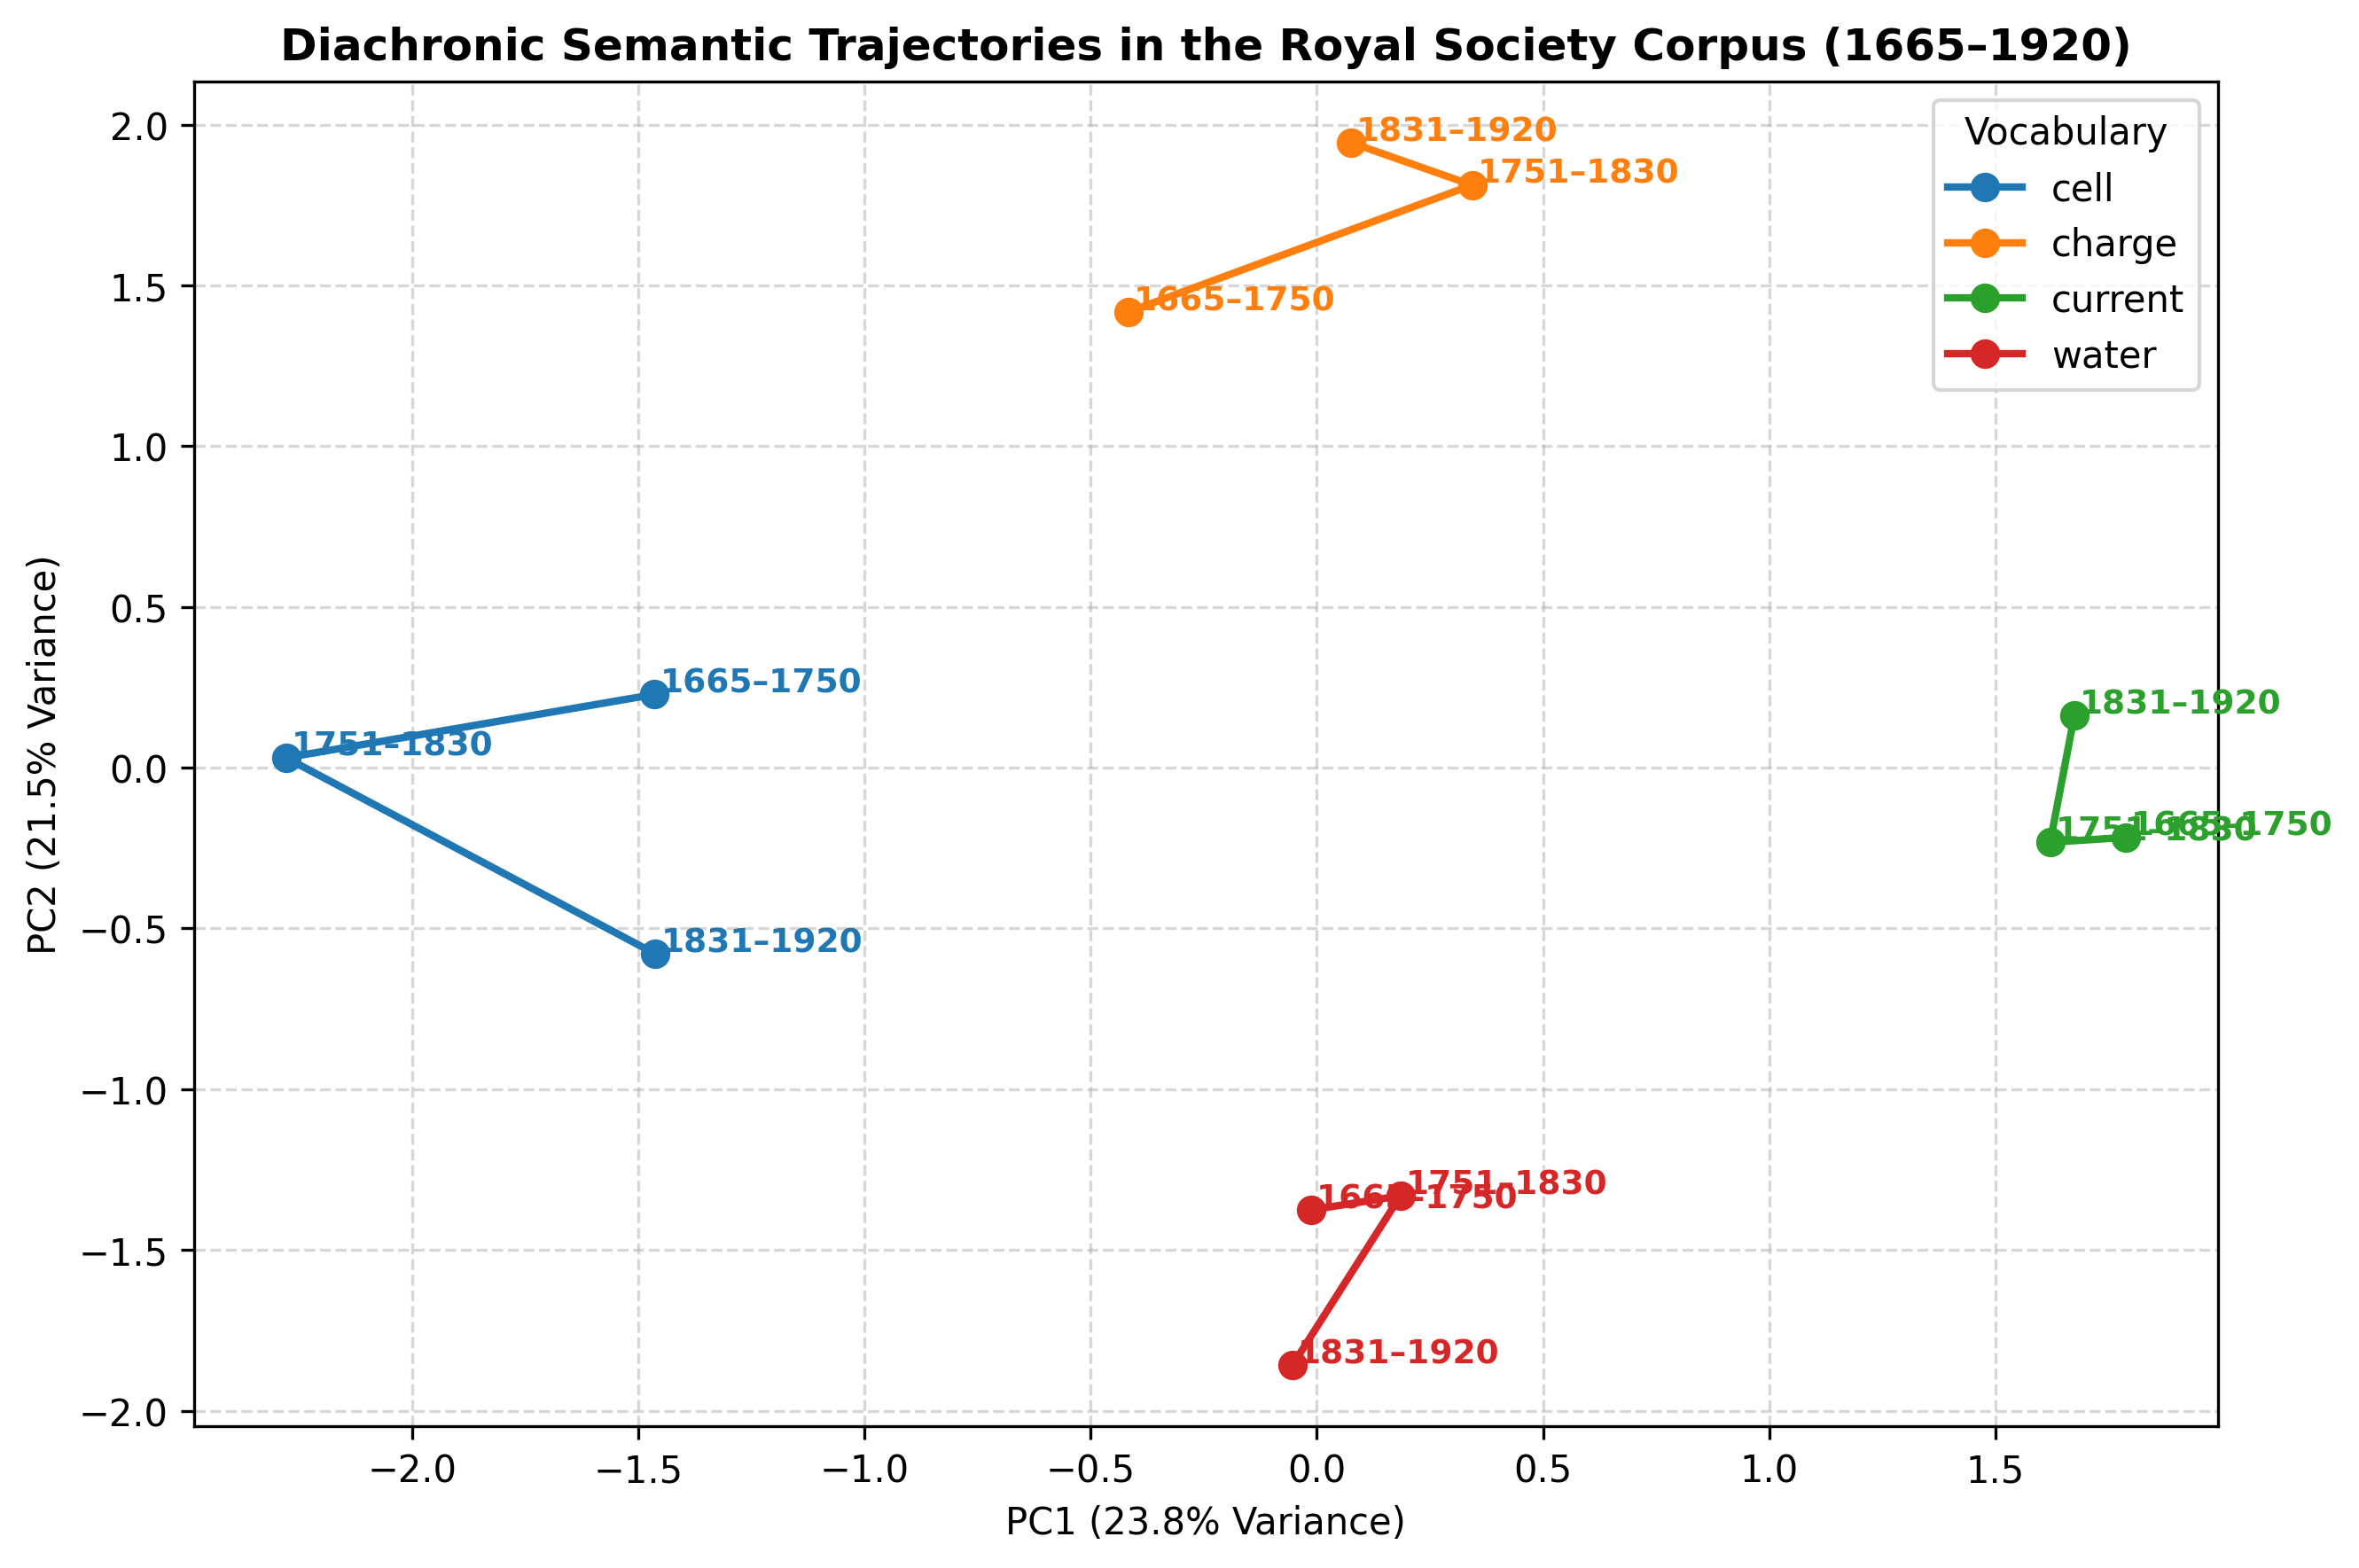

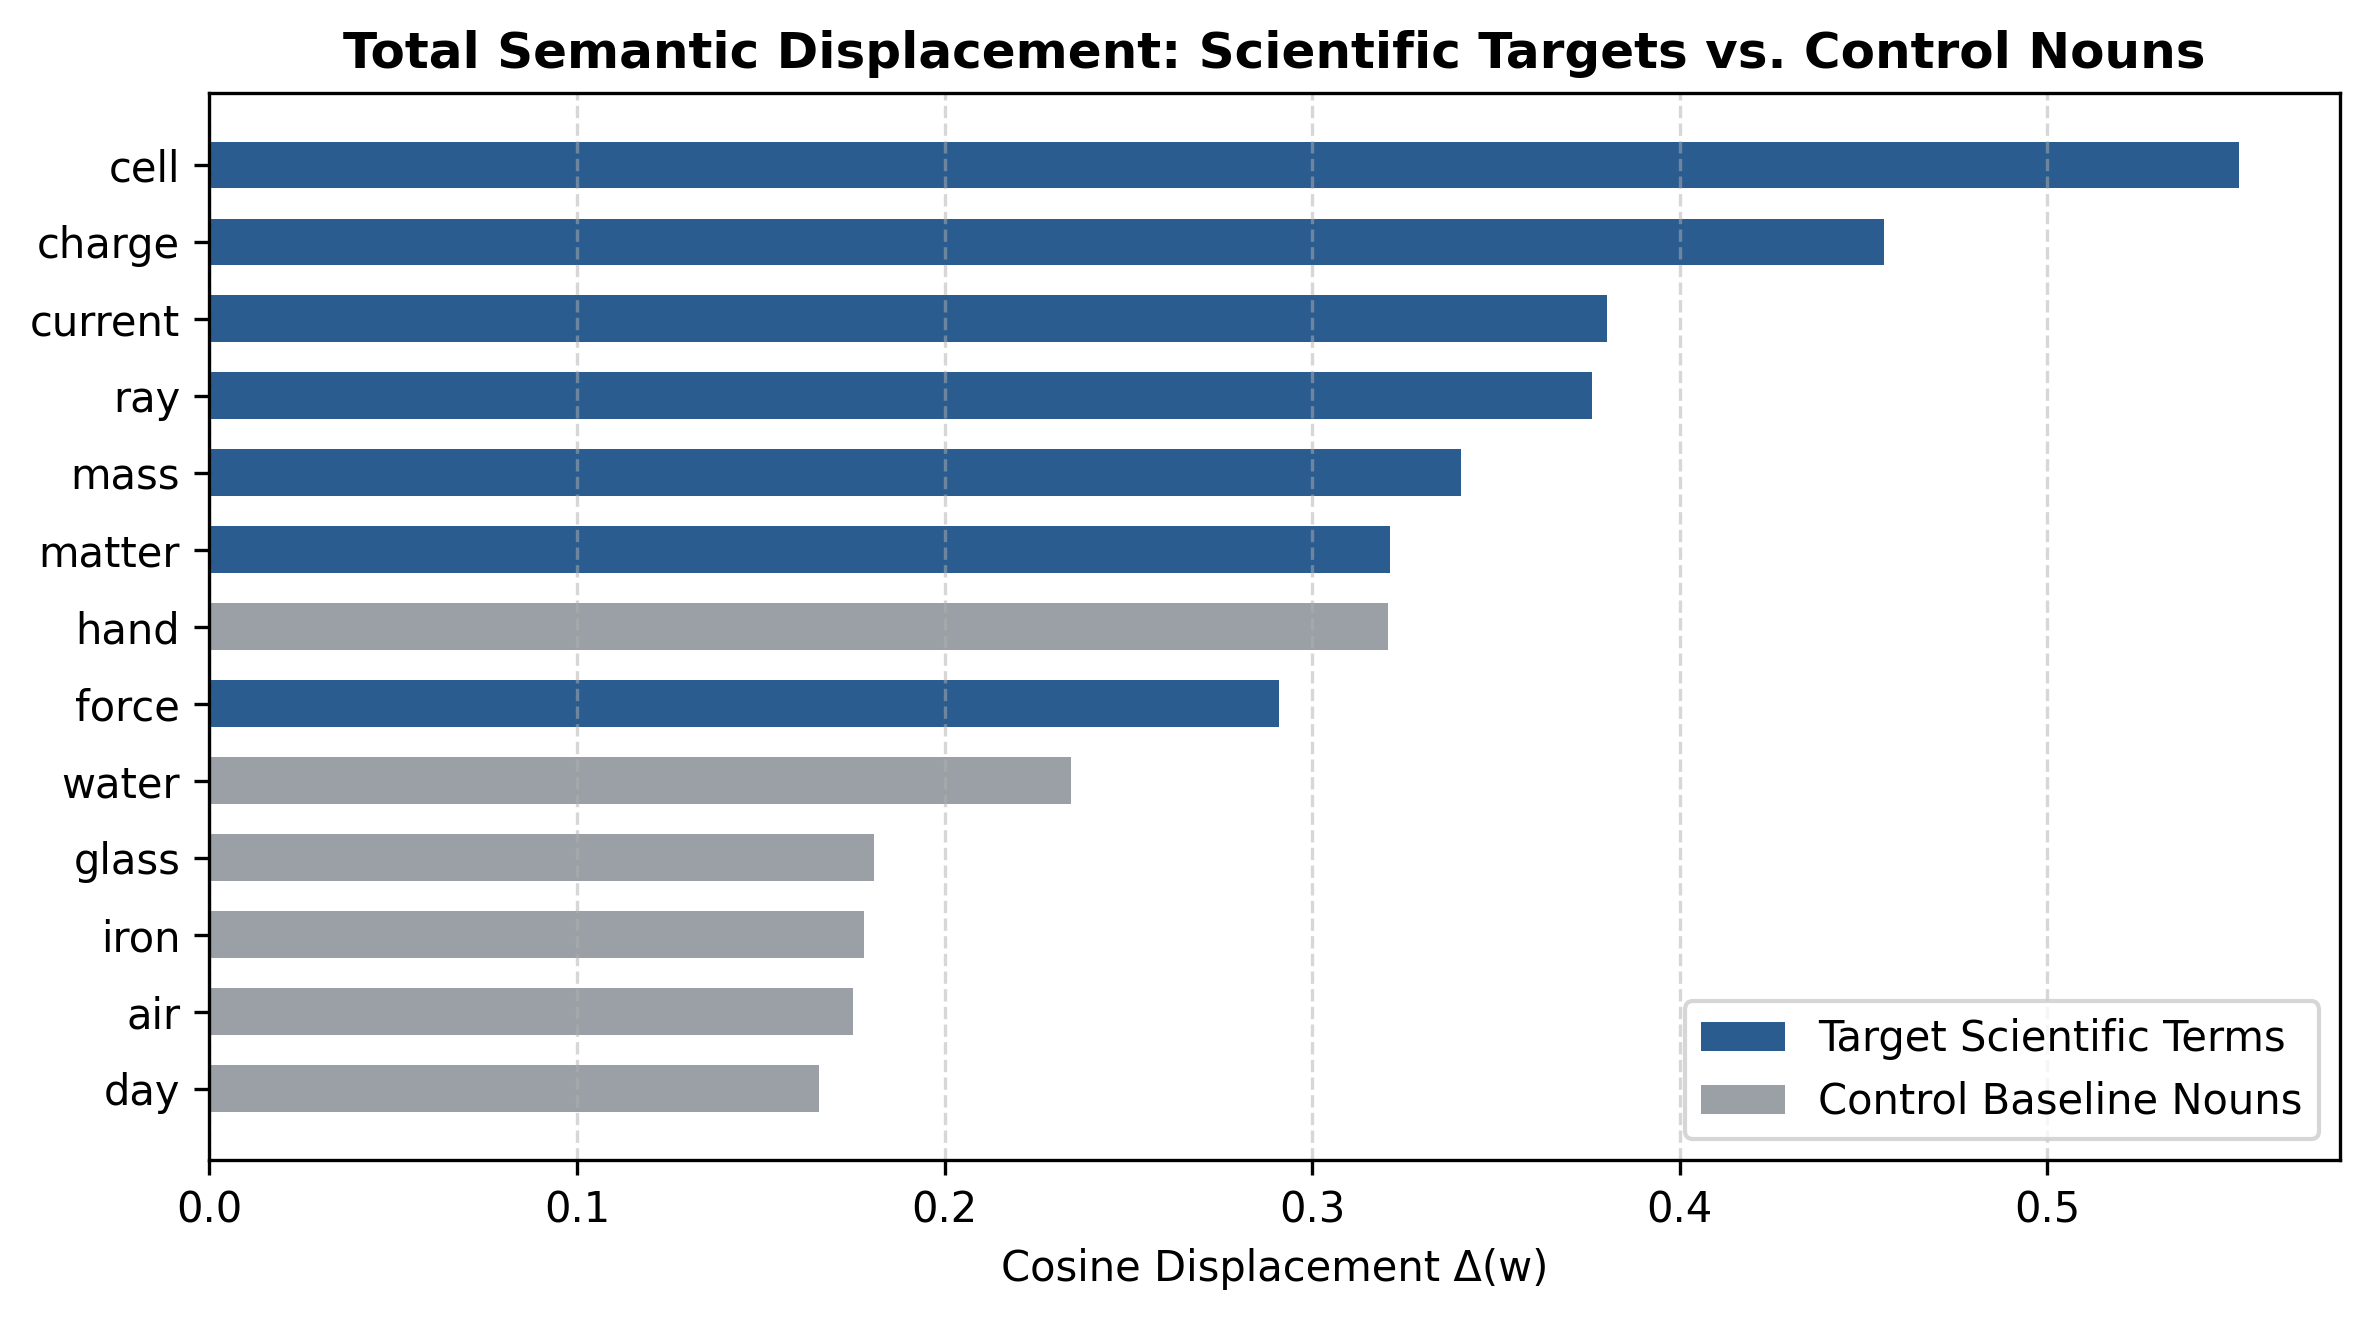

Visualizations saved: figure1_rsc_trajectories.png and figure2_rsc_displacement.png


In [6]:
#Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

key_words = [w for w in ["cell", "charge", "current", "water"] if w in shared_vocab]
pca_vectors, pca_tags = [], []

for w in key_words:
    for ep in epoch_keys:
        pca_vectors.append(aligned_vecs[ep][w])
        pca_tags.append((w, ep))

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(np.array(pca_vectors))

plt.figure(figsize=(9, 6), dpi=300)
colors = sns.color_palette("tab10", len(key_words))

for idx, word in enumerate(key_words):
    pts = [coords[i] for i, (tag_w, _) in enumerate(pca_tags) if tag_w == word]
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]

    plt.plot(xs, ys, "-o", color=colors[idx], label=word, linewidth=2, markersize=7)
    labels = ["1665–1750", "1751–1830", "1831–1920"]
    for k, (x, y) in enumerate(zip(xs, ys)):
        plt.text(x + 0.012, y + 0.008, labels[k], fontsize=9, color=colors[idx], weight="bold")

plt.title("Diachronic Semantic Trajectories in the Royal Society Corpus (1665–1920)", fontsize=12, weight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Vocabulary", frameon=True)
plt.tight_layout()
plt.savefig("figure1_rsc_trajectories.png")
plt.show()

plt.figure(figsize=(8, 4.5), dpi=300)
df_sorted = df_results.sort_values(by="total_disp", ascending=True)
bar_colors = ["#2b5c8f" if c == "Target" else "#9aa0a6" for c in df_sorted["category"]]

plt.barh(df_sorted["word"], df_sorted["total_disp"], color=bar_colors, height=0.6)
plt.title("Total Semantic Displacement: Scientific Targets vs. Control Nouns", fontsize=12, weight="bold")
plt.xlabel("Cosine Displacement Δ(w)")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.legend(handles=[
    Patch(facecolor="#2b5c8f", label="Target Scientific Terms"),
    Patch(facecolor="#9aa0a6", label="Control Baseline Nouns")
], loc="lower right")

plt.tight_layout()
plt.savefig("figure2_rsc_displacement.png")
plt.show()

print("Visualizations saved: figure1_rsc_trajectories.png and figure2_rsc_displacement.png")